# Install & Import Library

In [ ]:
!pip install optuna gensim spacy tensorflow scikit-learn

import numpy as np
import pandas as pd
import spacy
from gensim.models import KeyedVectors
import optuna
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.7 MB/s eta 0:00:00


# Load spaCy Tokenizer (Indonesia)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nlp = spacy.blank("id")  # tokenizer-only, paling cepat

def spacy_tokenize(text):
    return [t.text for t in nlp(text)]


# Load Dataset + Split Train/Val/Test :

In [ ]:
file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load FastText Embedding

In [ ]:
fasttext_path = "/content/drive/MyDrive/DistilBERT-7-Mei/cc.id.300.vec"

w2v = KeyedVectors.load_word2vec_format(fasttext_path, binary=False)

embedding_dim = 300


# Build Vocabulary + Convert to Sequence (Menggunakan spaCY)

In [ ]:
def build_vocab(texts):
    vocab = {}
    idx = 1  # 0 reserved for PAD

    for txt in texts:
        for tok in spacy_tokenize(txt):
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab) + 1


# Create embedding matrix:

In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))


# Convert text to indexed sequences:

In [ ]:
def text_to_sequence(text, vocab, max_len=40):
    tokens = spacy_tokenize(text)
    seq = [vocab.get(tok, 0) for tok in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def convert_dataset(X):
    return np.array([text_to_sequence(t, vocab) for t in X])

X_train_vec = convert_dataset(X_train)
X_val_vec = convert_dataset(X_val)
X_test_vec = convert_dataset(X_test)


# Build Bi-GRU Model (with ReLU + Dropout)

In [ ]:
def build_model(h_units, dropout_rate, lr):

    inp = Input(shape=(40,))
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    x = Bidirectional(GRU(h_units, return_sequences=False))(emb)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Optuna Objective with  K-Fold (K=5)

In [ ]:
# Optuna Objective TANPA K-Fold
def objective(trial):

    h_units = trial.suggest_int("h_units", 32, 128)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for tr_idx, va_idx in skf.split(X_train_vec, y_train):

        X_tr, X_va = X_train_vec[tr_idx], X_train_vec[va_idx]
        y_tr, y_va = y_train.values[tr_idx], y_train.values[va_idx]

        model = build_model(h_units, dropout_rate, lr)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=5,
            batch_size=32,
            verbose=0
        )

        preds = (model.predict(X_va) > 0.5).astype("int32")
        f1 = f1_score(y_va, preds)
        f1_scores.append(f1)

    return np.mean(f1_scores)


# Jalankan Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best = study.best_params
best


[I 2025-12-02 01:37:18,872] A new study created in memory with name: no-name-8901b995-df3c-435d-acbf-907215e315a1


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


[I 2025-12-02 01:37:50,553] Trial 0 finished with value: 0.8059867742353164 and parameters: {'h_units': 75, 'dropout': 0.31507184461209625, 'lr': 0.000720420737429735}. Best is trial 0 with value: 0.8059867742353164.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


[I 2025-12-02 01:38:18,437] Trial 1 finished with value: 0.7376684089281438 and parameters: {'h_units': 55, 'dropout': 0.37583336292260616, 'lr': 0.00045144328536978287}. Best is trial 0 with value: 0.8059867742353164.


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


[I 2025-12-02 01:59:11,254] Trial 48 finished with value: 0.8059459357279763 and parameters: {'h_units': 108, 'dropout': 0.17786509053893662, 'lr': 0.0038287230370436095}. Best is trial 35 with value: 0.8251651505752132.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


[I 2025-12-02 01:59:40,106] Trial 49 finished with value: 0.7164586854563811 and parameters: {'h_units': 103, 'dropout': 0.2962858969049654, 'lr': 0.00028059504567709624}. Best is trial 35 with value: 0.8251651505752132.


{'h_units': 84, 'dropout': 0.35808517777072174, 'lr': 0.0020139676938473214}

# Final Training on Train + Val

In [ ]:
best_h = best["h_units"]
best_drop = best["dropout"]
best_lr = best["lr"]

final_model = build_model(best_h, best_drop, best_lr)

X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

final_model.fit(
    X_final, y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5930 - loss: 0.6652
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8302 - loss: 0.3923
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8959 - loss: 0.2635
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9068 - loss: 0.2298
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9215 - loss: 0.2006
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9390 - loss: 0.1743
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9365 - loss: 0.1688
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9523 - loss: 0.1347
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9479 - loss: 0.1321
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9611 - loss: 0.0939


# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

         0.0     0.8784    0.8553    0.8667       228
         1.0     0.8281    0.8548    0.8413       186

    accuracy                         0.8551       414
   macro avg     0.8533    0.8551    0.8540       414
weighted avg     0.8558    0.8551    0.8553       414



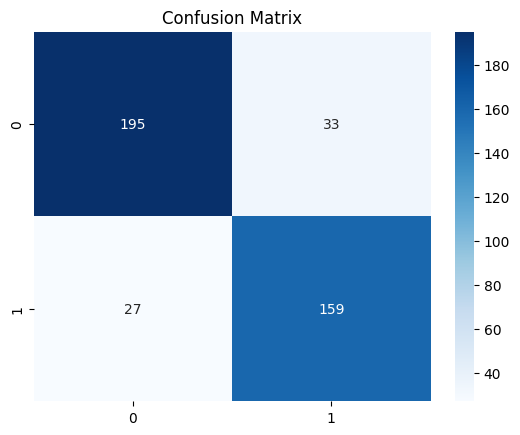

Macro F1: 0.853968253968254


In [ ]:
y_pred = (final_model.predict(X_test_vec) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


# Save Experiment Configuration

In [ ]:
import json
from pprint import pprint

experiment_config = {
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "bigru",
    "best_params": best,
    "embedding_dim": embedding_dim
}

print("\nExperiment Configuration:")
pprint(experiment_config)

print("\nJSON Format:")
print(json.dumps(experiment_config, indent=4))



Experiment Configuration:
{'best_params': {'dropout': 0.35808517777072174,
                 'h_units': 84,
                 'lr': 0.0020139676938473214},
 'embedding': 'fasttext',
 'embedding_dim': 300,
 'model': 'bigru',
 'tokenizer': 'spacy'}

JSON Format:
{
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "bigru",
    "best_params": {
        "h_units": 84,
        "dropout": 0.35808517777072174,
        "lr": 0.0020139676938473214
    },
    "embedding_dim": 300
}


In [ ]:
best_h = 56
best_drop = 0.4527780273590106
best_lr = 0.0023329771976242637

final_model = build_model(best_h, best_drop, best_lr)

# Combine train + val
X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

# Train final BiGRU
final_model.fit(
    X_final,
    y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)

# === Evaluation on TEST set ===
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_pred = final_model.predict(X_test_vec)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

f1_macro = f1_score(y_test, y_pred, average="macro")
cls_report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Final BiGRU Test Evaluation ===")
print("F1-macro:", f1_macro)
print("Accuracy:", cls_report["accuracy"])
print("Classification Report:", cls_report)
print("Confusion Matrix:\n", cm)

# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(X_test_vec))
subset = X_test_vec[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset, verbose=0)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset, verbose=0)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5800 - loss: 0.6682
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8086 - loss: 0.4478
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8572 - loss: 0.3355
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9087 - loss: 0.2484
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9005 - loss: 0.2552
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8936 - loss: 0.2372
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9317 - loss: 0.1833
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9326 - loss: 0.1607
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9457 - loss: 0.1519
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9465 - loss: 0.1463
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

=== Final BiGRU Test Evaluation ===
F1-macro: 0.8579007268150807
Accuracy: 0.8623188405797102
Classification Rep